# Optimization for AI Project - Deiana

For this project, we will explore and try to design a GA algorithm to automatically synthesize FIR filters according to a desired frequency response. We will start with an "abstract" baseline proof of concept, and then we will take inspiration from a couple of papers to produce more useful and realistic results.

A digital FIR filter is characterized by the following transfer function: $H(s)=\sum^{N}_{n=0}a_nz^{-n}$, where $N$ is the order of the filter, and $a_n$ are
defined as the filter coefficients.
As we can see, an individual in this case is simply a vector in $\mathbb{R}^N$, which allows us to inherit all the literature about real-valued GAs.

In reality, digital FIR filters are designed to be implemented in hardware. This presents us with a couple of challenges, namely that hardware costs increase with the order of the filter and the way it's implemented.
As we will later see, a particular ternary encoding called CSD is preferred, as it allows to automatically synthesize a filter from the provided genome and saves up on circuit complexity.
 This, in turn, means that the real-valued GAs, which are quite simple to implement in software, are not desirable for real-world FIR filter design. Nonetheless, precisely because of its simplicity,
 we will first implement a real-valued version of the GA as a baseline, and compare it wrt. execution speed, convergence speed, and fitness with the algorithms proposed in the papers.

## **0. Real-valued GA**

Before we implement the techniques proposed in the papers, it could be interesting to create a simple proof of concept at a higher level. We will implement the classic GA structure, and encode the individuals as simple vectors of real numbers. This will allow us to reuse much of the code when implementing the papers.

The GA will be implemented as follows:
- Chromosome: $x=(x_1,…,x_n)$, where $X \in [-1, 1]^n$
- Init: Uniform sampling
- Mutation: Gaussian (adjusted to stay in $[-1, 1]$)
- Crossover: Two-point crossover, Discrete recombination
- Selection: Roulette Wheel, Tournament
- Fitness: Minimax, LMS, MSE
- Elitism: 5% of the population [TOGGLEABLE]

We will use the signal library from Scipy for calculating the frequency response of each individual, together with numpy. For everything else, standard python is enough to implement the GA.

### Implementation

In [58]:
import random, bisect
from itertools import count
from xxlimited_35 import Null

import numpy as np
from scipy.signal import freqz

#### Initialization
In FIR filters, there is a big difference between a coefficient being exactly zero or being nonzero. For this reason, the sampling has a 50% chance of being uniform between -1 and 1 or being precisely 0. Furthermore, simpler filters don't have many nonzero coefficients, thus this can be a better starting point than uniform sampling everything.

In [59]:
def init_individual(order):
    individual = []
    for _ in range(order):
        individual.append(random.choice([random.uniform(-1, 1), 0]))
    return individual

In [60]:
def init_pop(order, n_pop):
    return [init_individual(order) for _ in range(n_pop)]

#### Mutation
For the same reason as initialization, an additional probability is required that will zero the coefficient, otherwise it's extremely unlikely that it would mutate uniformly to become exactly zero. On top of that, since we want to remain in the boundaries of $[-1,1]$, the usual gaussian mutation has been altered to take the boundaries into account.

In [61]:
def mut(individual, p=0.01, pz=0.01):
    mutated = []
    for coeff in individual:
        if random.random() < p:
            mutated.append(coeff + random.gauss(sigma=1 - abs(coeff)))  # We want to remain in the [-1, 1] range
        else:
            if random.random() < pz:
                mutated.append(
                    0)  # Since exact zeroes are very important, sometimes we want to force a coefficient to 0 to see if things improve
            mutated.append(coeff)
    return mutated

#### Crossover
Real-valued GAs allow us to use recombination crossover to produce offspring "between" real vectors. However, since we plan to reuse as much code as possible, we also implement two-point crossover between the two vectors. This will become useful later since we will not perform crossover between the individual coefficients' binary strings, so this algorithm will not need to be modified and will work the same on all implementations.

In [62]:
def twopoint_cross(p1, p2):
    indexes = random.sample(range(1, len(p1) - 1), 2)
    indexes.sort()
    return p1[:indexes[0]] + p2[indexes[0]:indexes[1]] + p1[indexes[1]:], p2[:indexes[0]] + p1[indexes[0]:indexes[1]] + p2[indexes[1]:]


def recomb_cross(p1, p2):
    child = []
    for p, q in zip(p1, p2):
        a = random.uniform(0, 1)
        child.append(a * p + (1 - a) * q)
    return child

#### Fitness(es)
Taking inspiration from the paper(s), in FIR filters design there are a few error measures that can be used. Naturally, our fitness function will be a negative error one. The chosen error metrics are as follows:
- **Minimax error ( $L_\infty$ norm ):** $ E_{\text{minimax}} = \max_{i=1,\dots,N} \left| H(j\omega_i) - \hat{H}(j\omega_i) \right|$
- **LMS (Least Mean Squares):** $E_{\text{LMS}} = \sum_{i=1}^{N} \left| H(j\omega_i) - \hat{H}(j\omega_i) \right|^2$
- **MSE (Mean Squared Error):** $E_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} \left| H(j\omega_i) - \hat{H}(j\omega_i) \right|^2$

Since the designers or a FIR filter might only be interested in the magnitude of the frequency response, we also customize the error functions to work both in complex and magnitude (and phase) mode. This allows us also to test how much, if any, considering just the magnitude produces better solutions or faster convergence, since calculating the error of complex numbers could be considered almost a multiobjective approach.


In [63]:
def _response_diff(individual, target, mode="complex"):
    w, Hi = freqz(individual)  # Hi : complex array
    Ht = np.array([target(wi) for wi in w], dtype=complex)

    if mode == "complex":
        diff = Ht - Hi

    elif mode == "magnitude":
        diff = np.abs(Ht) - np.abs(Hi)

    elif mode == "phase":
        # unwrap to avoid 2π discontinuities
        ph_t = np.unwrap(np.angle(Ht))
        ph_i = np.unwrap(np.angle(Hi))
        diff = ph_t - ph_i

    else:
        raise ValueError("mode must be 'complex', 'magnitude', or 'phase'")

    return diff


def minimax_error(individual, target, mode="complex"):
    diff = _response_diff(individual, target, mode=mode)
    return np.max(np.abs(diff))


def lms_error(individual, target, mode="complex"):
    diff = _response_diff(individual, target, mode=mode)
    return np.linalg.norm(diff)  # sqrt(sum |diff|^2)


def mse_error(individual, target, mode="complex"):
    diff = _response_diff(individual, target, mode=mode)
    return np.mean(np.abs(diff) ** 2)  # mean(|Δ|^2)


def minimax_fit(individual, target, mode="complex"):
    return -minimax_error(individual, target, mode=mode)


def lms_fit(individual, target, mode="complex"):
    return -lms_error(individual, target, mode=mode)


def mse_fit(individual, target, mode="complex"):
    return -mse_error(individual, target, mode=mode)


#### Selection
In the papers, roulette and ranking selections are used and compared. We choose to only implement roulette selection but add tournament selection for comparison. This is because tournament selection is the standard selection algorithm in most cases, and as such can give us a more interesting comparison.

In [64]:
def roulette_selection(pop, n_pop, fitness, target, mode):
    # Compute raw fitness values (possibly negative)
    fvals = np.array([fitness(ind, target, mode) for ind in pop], dtype=float)

    # Shift to strictly positive (critical!)
    fvals = fvals - fvals.min() + 1e-12

    # Build cumulative distribution
    cum = np.cumsum(fvals)
    tot = cum[-1]

    newpop = []
    for _ in range(n_pop):
        r = random.random() * tot
        idx = bisect.bisect_left(cum, r)

        # clamp index (avoid floating point overshoot)
        if idx >= len(pop):
            idx = len(pop) - 1

        newpop.append(pop[idx])

    return newpop


def tournament_selection(pop, n_pop, fitness, target, mode, k=3):
    newpop = []
    while len(newpop) < n_pop:
        contestants = random.choices(population=pop, k=k)
        contestants.sort(key=lambda x: fitness(x, target, mode), reverse=True)
        newpop.append(contestants[0])
    return newpop


def selection(pop, n_pop, fitness, target, mode, strategy=roulette_selection):
    return strategy(pop, n_pop, fitness, target, mode)

#### GA
We implement a standard GA structure. Although the papers do not make use of elitism, we nonetheless implement it for optional use due to its noticeable improvements over the base GA structure. If elitism is not selected, we cannot guarantee that the last generation will contain the best ever solution, thus we append the best of the entire history of the GA to the end.

In [65]:
def GA(n_pop, generations, order, target, fitness, elitism=False, mode="complex"):
    best = []
    elites_n = int(n_pop / 100 * 5) if elitism else 0
    # Population initialization
    pop = init_pop(order, n_pop)
    for _ in range(generations):
        pop.sort(key=lambda x: fitness(x, target, mode), reverse=True)
        elites = pop[:elites_n]
        best.append(pop[0])
        for _ in range(n_pop):
            parent1 = pop[random.randint(0, len(pop) - 1)]
            parent2 = pop[random.randint(0, len(pop) - 1)]
            child = mut(recomb_cross(parent1, parent2))
            pop.append(child)
        pop = selection(pop, n_pop - elites_n, fitness, target, mode)
        pop.extend(elites)
    if elitism: best.append(max(best, key=lambda x: fitness(x, target, mode)))
    return best

### Testing basic FIR filters
Before doing any side-by-side comparisons, we will see how the GA behaves on very simple filter designs.

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)
COLORS = {
    "minimax": sns.color_palette("deep")[0],
    "lms": sns.color_palette("deep")[2],
    "mse": sns.color_palette("deep")[4],
    "target": sns.color_palette("deep")[3],
}

In [10]:
N_chrom = 100
generations = 100
order = 8

In [11]:
modes = ["complex", "magnitude"]
metrics = ["minimax", "lms", "mse"]

In [12]:
# ================================================================
# 2. Helper functions for plotting
# ================================================================
def compute_FR(individual, worN=2048):
    w, H = freqz(individual, worN=worN)
    Ht = np.array([target(wi) for wi in w], dtype=complex)
    return w, H, Ht


def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

#### 0. Ideal all-pass filter

In [13]:
def target(w):
    return 1

#### 1. Ideal high-pass filter

In [14]:
def target(w):
    return 1 if w >= 1.5 else 0

In [15]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA(N_chrom, generations, order, target, minimax_fit, elitism=False, mode=mode)
    results[(mode, "lms")] = GA(N_chrom, generations, order, target, lms_fit, elitism=False, mode=mode)
    results[(mode, "mse")] = GA(N_chrom, generations, order, target, mse_fit, elitism=False, mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


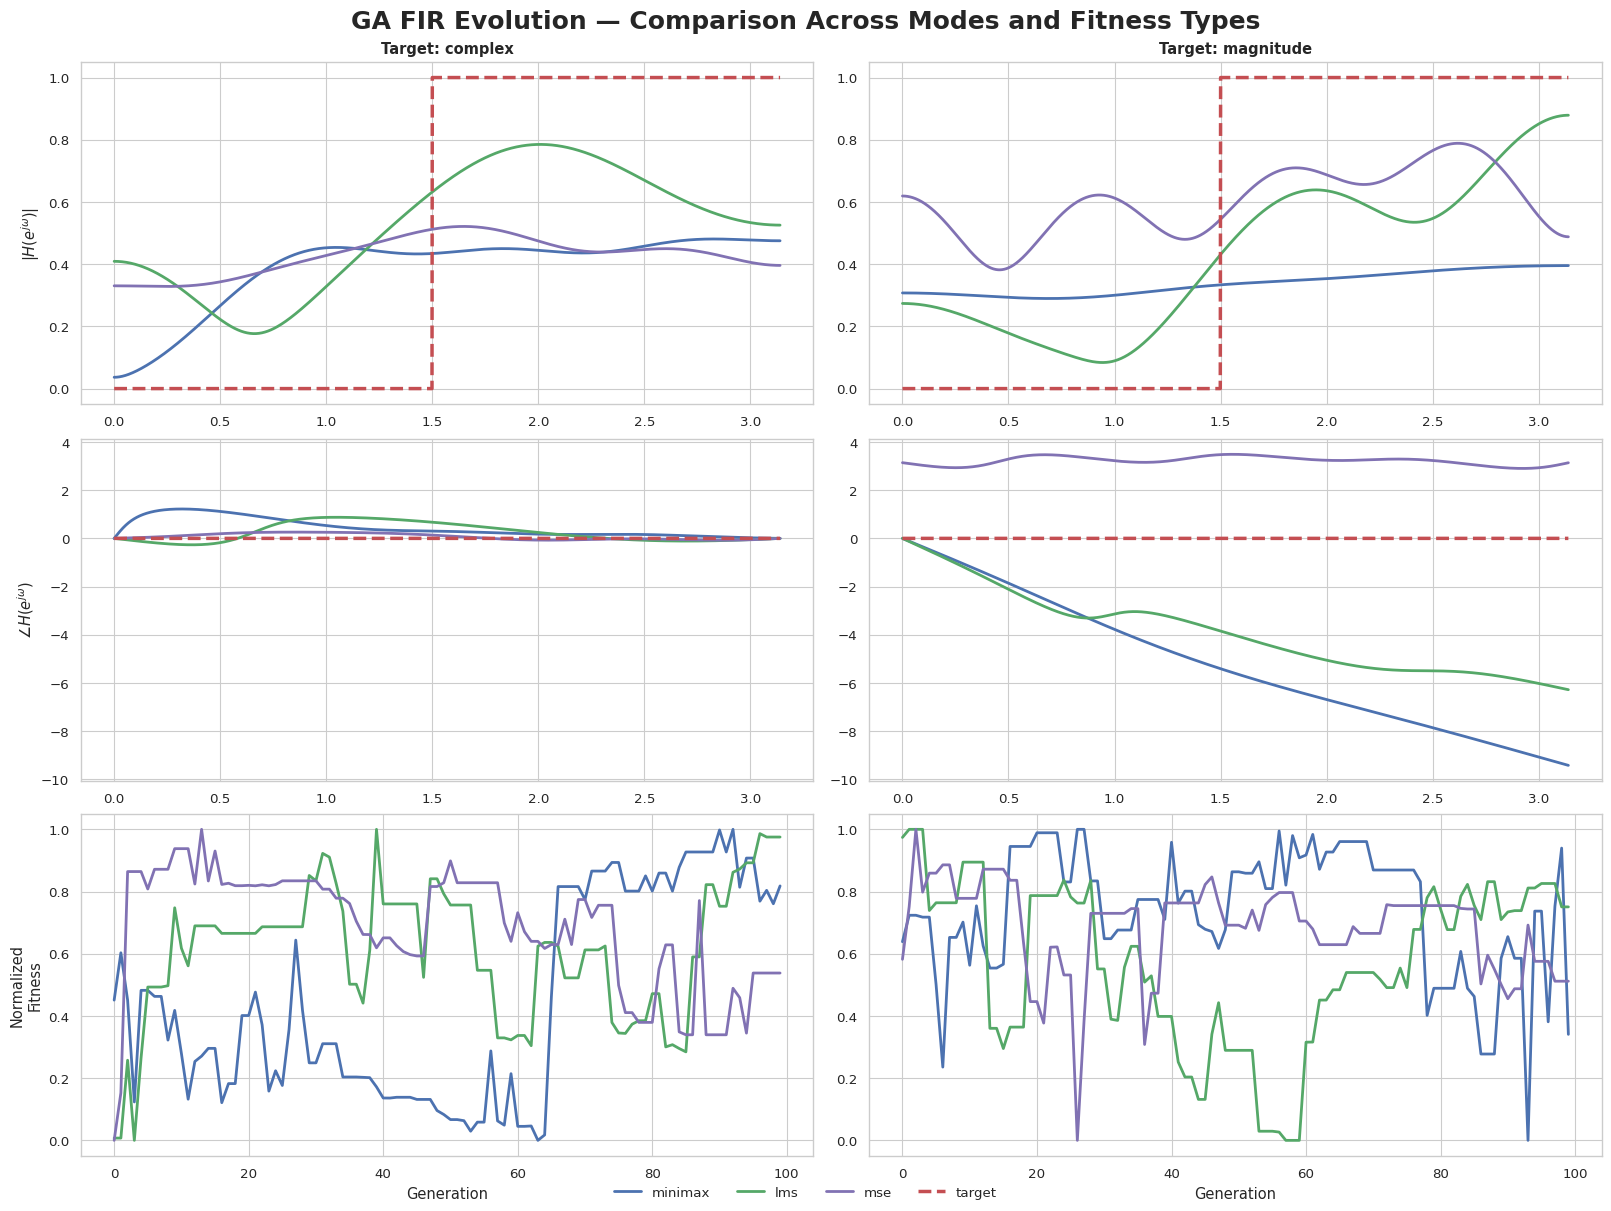

In [16]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR(b_minimax)
    _, H_lms, _ = compute_FR(b_lms)
    _, H_mse, _ = compute_FR(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

#### 2. Ideal band-pass filter

In [17]:
def target(w):
    return 0 if w >= 2 or w <= 1 else 1

In [18]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA(N_chrom, generations, order, target, minimax_fit, elitism=False, mode=mode)
    results[(mode, "lms")] = GA(N_chrom, generations, order, target, lms_fit, elitism=False, mode=mode)
    results[(mode, "mse")] = GA(N_chrom, generations, order, target, mse_fit, elitism=False, mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


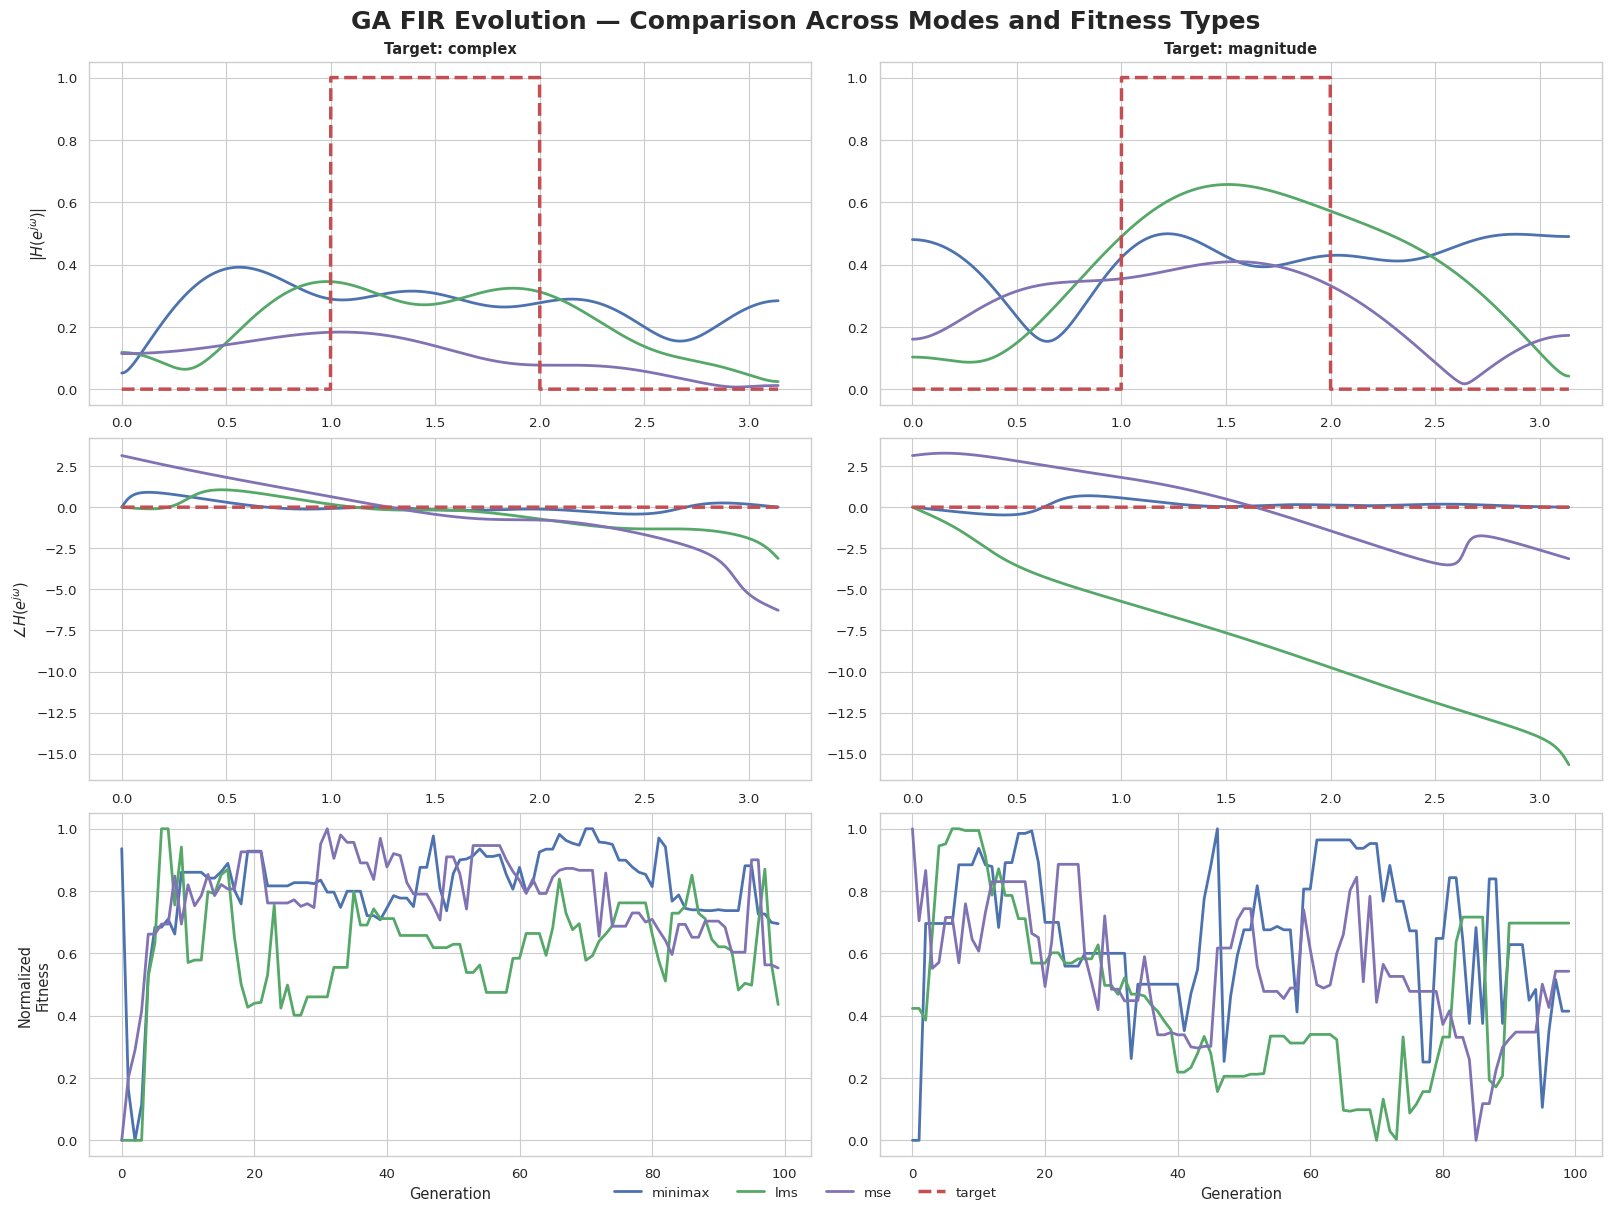

In [19]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR(b_minimax)
    _, H_lms, _ = compute_FR(b_lms)
    _, H_mse, _ = compute_FR(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

#### 3. Ideal differentiator

In [20]:
def target(w):
    return w

#### 4. Ideal Hilbert Transformer

In [21]:
def target(w):
    if w == 0 or w == np.pi:
        return 0.0
    return -1j

#### 5. Ideal Fractional Delay Filter

In [22]:
def target(w, D=0.4):
    return np.exp(-1j * w * D)

#### 6. Ideal Root‑Raised‑Cosine (RRC) Filter

In [23]:
def target(w, alpha=0.25, ws=np.pi):
    w = abs(w)
    if w <= (1 - alpha) * ws / 2:
        return 1.0
    elif (1 - alpha) * ws / 2 < w <= (1 + alpha) * ws / 2:
        return 0.5 * (1 + np.cos(np.pi / (alpha * ws) * (w - (1 - alpha) * ws / 2)))
    else:
        return 0.0

#### 7. Gaussian Low‑Pass Filter

In [24]:
def target(w, sigma=0.5):
    return np.exp(-(sigma ** 2) * (w ** 2) / 2)

#### 8. Derivative of Gaussian (DoG) Filter

In [25]:
def target(w, sigma=0.5):
    return 1j * w * np.exp(-(sigma ** 2) * (w ** 2) / 2)

#### 9. Arbitrary Complex Equalizer

In [26]:
def target(w, G=lambda x: -20 * np.log10(1 + x)):
    mag = 10 ** (G(w) / 20.0)
    return mag

#### 10. Multiband Filter (example: pass–stop–pass)

In [27]:
def target(w, bands=None):
    if bands is None:
        bands = [(0, np.pi / 4), (np.pi / 2, 3 * np.pi / 4)]
    for (a, b) in bands:
        if a <= w <= b:
            return 1.0
    return 0.0

### Observations
As it was expected, computing the fitness over the complex response allows our solutions to get close both in magnitude and phase. If instead we just care about the magnitude, we can reach much better convergence to the desired response, at the price of a completely arbitrary phase. The papers only care about the latter, but it was interesting to showcase this distinction nonetheless.

## **1. CSD-compatible GA** by _A.Lee, M. Ahmadi, G.A. Jullien, et al._

Designing a filter using infinite-precision real coefficients, like we did in the previous example, inevitably leads to _quantization_ and _truncation_ errors when implementing them in finite-precision hardware. It is only natural to ask ourselves if there is a way to _directly_ evolve these filters in their _"native"_ representation, such that the evolved solution is as close as possible to its real world counterpart. Not only that, is it also possible to automatically evolve a solution that will produce the _least amount of complexity_ in the final filter hardware? This is the question the chosen paper tries to answer. Regarding the _finite precision_ requirement, we will work with a **finite wordlength** chosen by the filter designer. In order to _minimize the complexity_ of the resulting circuitry, a particular set of constraints will be used called **CSD representation**. Additionally, a **maximum number of nonzero digits**  $N_{\text{digits}}$ within each coefficient will be chosen by the designer to further limit the complexity of the filter.

### CSD theory

CSD (Canonical Signed Digit) is a **radix‑2 signed‑digit number system** where each digit takes values: $d_k \in \{-1, 0, +1\}$, and is associated with the power‑of‑two term $2^k$.
CSD imposes a structural constraint, namely that **no two adjacent digits may be non‑zero**: $d_k \neq 0 \;\Rightarrow\; d_{k-1} = d_{k+1} = 0.$ This rule guarantees a **unique representation** with the **minimum possible Hamming weight** among all radix‑2 signed-digit expansions.

In an FIR filter,

$$
y[n] = \sum_{k=0}^{N-1} h[k]\,x[n-k],
$$

each multiplication becomes:

$$
h[k]\cdot x[n-k]=
(\sum_i d_{k,i} 2^{e_{k,i}})\cdot x[n-k]=
\sum_i d_{k,i}\,(x[n-k] \ll e_{k,i}),
$$

As such, using a CSD representation:
- **Multipliers vanish**
- Adds/subs are **minimized** due to the minimal Hamming weight.

In FIR filters this yields the smallest, fastest, and most power‑efficient hardware implementation of fixed coefficients.



#### Encodings
The paper propose 2 different encodings for each coefficient $h[k]$: **ternary** and **mixed**.

- In the **ternary** encoding, a filter coefficient is represented by a string of ternary digits. Each of the ternary digits
corresponds to a power-of-two (POT) number. Thus, the i-th coefficient of the filter is: $h_i=d_{0_i} \times 2^0 + d_{1_i} \times 2^{-1} + \dots + d_{m_i} \times 2^{-m_i}$. This means that we waste space encoding unused powers of 2. The length of each ternary string is equivalent to the wordlength of the filter coefficient.

- In the **mixed** encoding, each filter coefficient is represented by the combination of ternary digits and binary strings. In this case, the string encodes directly the desired POT exponents. In fact, the string's structure is as follows: $|s_0|b_{0_1} \dots b_{0_p}| \dots |s_m|b_{m_1} \dots b_{m_p}|$, where $s_i \in \{-1, 1\}$, $b_{i_j} \in \{0,1\}$, and $p$ is the precision with which we encode the POT exponent. Thus, the i-th coefficient of the filter is: $h_i=s_{0_i} \times 2^{k_{0_i}} + \dots + s_{m_i} \times 2^{k_{m_i}}$, where $k_{j_i}$ is the real number encoded by $b_{j_{1_i}} \dots b_{j_{p_i}}$. The wordlength of a filter coefficient is bounded by the maximum value of the exponent, $(m_i + 1)$.  Only non-zero POT digits are encoded for mixed encoding, whereas the whole filter coefficient including the zero digits is encoded for ternary encoding.

Unfortunately, the paper does not properly describe how the mixed encoding is actually implemented and how mutation and crossover would work with it, never mind what it would mean for an individual to be in CSD form. For this reason, we will only implement and test the ternary encoding.

### Implementation

Since we already wrote a complete GA for the real-valued case, this change in genome will only require a few modifications.

#### Utilities

As the first order of business, we write some utilities to make our lives easier. Since the genome of an individual is a single list of symbols, but each coefficient has to be treated separately, we implement some functions to extract and merge coefficients automatically and convert them to real numbers.

In [88]:
def genomeToCoeffs(genome, wordlength):
    return [genome[i:(i + wordlength)] for i in range(0, int(len(genome)/wordlength), wordlength)]

def coeffsToGenome(coeffs):
    genome = []
    for coeff in coeffs:
        genome.extend(coeff)
    return genome

def CSDtoReal(CSDcoeff):
    r = 0
    for i in range(0, len(CSDcoeff)):
        r += CSDcoeff[i]*(2 ** (-i))
    return r

def genomeToRealCoeffs(genome, wordlength):
    return [CSDtoReal(coeff) for coeff in genomeToCoeffs(genome, wordlength)]

#### CSD Check
We write a utility function to make sure an individual is CSD-encoded and, in general, valid.

In the **ternary** case, an individual is CSD-compliant if, for each coefficient:
- Given two adjacent digits $d_i, d_{i+1} \quad d_i \times d_{i+1} = 0$
- The number of nonzero digits doesn't exceed a provided $N_{\text{digits}}$

In [89]:
def isTernaryIndividualCSD(genome, wordlength, N_digits):
    broken_coeffs = []
    coeffs = genomeToCoeffs(genome, wordlength)
    for i in range (0, len(coeffs)):
        coeff = coeffs[i]
        if len([symbol for symbol in coeff if symbol not in [0]]) > N_digits:
            broken_coeffs.append(i)
            continue
        for j in range (0, len(coeff)-1):
            if coeff[j]*coeff[j+1] != 0:
                broken_coeffs.append(i)
                break
    return True, [] if len(broken_coeffs) == 0 else False, broken_coeffs

#### Initialization
As per the paper: _Each chromosome within a population is cascaded of
encoded filter coefficients, such that each coefficient is
initialized by a non-zero power-of-two digit._ This translates into setting a single bit to nonzero per coefficient in the ternary case.

In [100]:
def init_CSD_coeff(wordlength):
    coeff = [0] * wordlength
    coeff[random.randint(0, wordlength-1)] = random.choice([-1, 1])
    return coeff

def init_individual_CSD(order, wordlength):
    return coeffsToGenome([init_CSD_coeff(wordlength) for _ in range(0, order)])

def init_pop_CSD(N_chrom, order, wordlength):
    return [init_individual_CSD(order, wordlength) for _ in range(N_chrom)]

#### Mutation

For **ternary** encoding, a mutation is equal to a random choice between $\{-1, 0, 1\} \setminus \{symbol\}$. For the **mixed** encoding, the mutation follows the semantics of the encoding (this is a personal choice), thus, when mutating a sign symbol, the choice is still between $\{-1, 0, 1\} \setminus \{symbol\}$, while when mutating an exponent symbol the choice is a simple bit flip. _(We don't have to worry if a sign symbol is mutated to 0 since that is taken into account and the entire POT will be ignored even if the exponent is nonzero)_

In [91]:
def mut_CSD(individual, p_mut=0.01):
    mutated = []
    for symbol in individual:
        if random.random() < p_mut:
            choices = [-1, 0, 1]
            choices.remove(symbol)
            mutated.append(random.choice(choices))
        else:
            mutated.append(symbol)
    return mutated

#### Fitness
The fitness calculation remains mostly the same, except we immediately convert through the use of a helper function the ternary coefficients into real numbers. By doing this, we can make use of the previously defined error functions.

In [107]:
def minimax_fit_CSD(individual, target, mode, wordlength):
    return minimax_fit(genomeToRealCoeffs(individual, wordlength), target, mode)

def lms_fit_CSD(individual, target, mode, wordlength):
    return lms_fit(genomeToRealCoeffs( individual, wordlength), target, mode)

def mse_fit_CSD(individual, target, mode, wordlength):
    return mse_fit(genomeToRealCoeffs( individual, wordlength), target, mode)

def CSD_fit_to_real_fit(fitness, wordlength):
    return partial(fitness, wordlength=wordlength)


#### GA
Due to the addition of the d_max parameter we need to modify our GA function. Furthermore, since we do not perform the mutation in a way that is compatible with CSD, we follow the paper's instructions of checking the CSD validity of every child and retrying crossover and mutation until compliant. If the number of retries exceeds $N_{\text{max}}$, the child becomes a newly initialized individual.

In [104]:
def GA_CSD(N_chrom, generations, order, wordlength, target, fitness, N_digits, N_max, elitism=False, mode="complex"):
    best = []
    N_elites = int(N_chrom / 100 * 5) if elitism else 0

    # Population initialization
    pop = init_pop_CSD(N_chrom, order, wordlength)

    for _ in range(generations):
        pop.sort(key=lambda x: fitness(x, target, mode, wordlength), reverse=True)
        elites = pop[:N_elites]
        best.append(pop[0])
        for _ in range(N_chrom):
            p1 = pop[random.randint(0, len(pop) - 1)]
            p2 = pop[random.randint(0, len(pop) - 1)]
            n_tries = 0
            #while n_tries <= N_max:
            c1, c2 = twopoint_cross(p1, p2)
            c1 = mut_CSD(c1)
            c2 = mut_CSD(c2)

            #c1, c2 = cross(p1, p2)
            pop.extend([c1, c2])
        pop = selection(pop, N_chrom - N_elites, CSD_fit_to_real_fit(fitness, wordlength), target, mode)
        pop.extend(elites)
    if elitism: best.append(max(best, key=lambda x: fitness(x, target, mode, wordlength)))
    return best

### Testing basic filters
Before doing any side-by-side comparisons, we will see how the GA behaves on very simple filter designs.

In [94]:
N_digits = 3
N_max = 20
worN = 1024
wordlength = 8

In [95]:
def compute_FR_CSD(individual, worN, wordlength):
    Ht = np.array([target(wi) for wi in w], dtype=complex)
    return w, H, Ht

#### 1. Ideal high-pass filter

In [96]:
def target(w):
    return 1 if w >= 1.5 else 0

In [108]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA_CSD(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, N_max, elitism=False,
                                        mode=mode)
    results[(mode, "lms")] = GA_CSD(N_chrom, generations, order, wordlength, target, lms_fit_CSD, N_digits, N_max, elitism=False,
                                    mode=mode)
    results[(mode, "mse")] = GA_CSD(N_chrom, generations, order, wordlength, target, mse_fit_CSD, N_digits, N_max, elitism=False,
                                    mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


In [ ]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR_CSD(b_minimax)
    _, H_lms, _ = compute_FR_CSD(b_lms)
    _, H_mse, _ = compute_FR_CSD(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit_CSD(b, target, mode, enc_type)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

#### 2. Ideal band-pass filter

In [ ]:
def target(w):
    return 0 if w >= 2 or w <= 1 else 1

In [ ]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA_CSD(N_chrom, generations, order, target, minimax_fit_CSD, N_max, N_max, elitism=False,
                                        mode=mode)
    results[(mode, "lms")] = GA_CSD(N_chrom, generations, order, target, lms_fit_CSD, N_max, N_max, elitism=False,
                                    mode=mode)
    results[(mode, "mse")] = GA_CSD(N_chrom, generations, order, target, mse_fit_CSD, N_max, N_max, elitism=False,
                                    mode=mode)

print("✓ GA runs completed.")

In [ ]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR_CSD(b_minimax)
    _, H_lms, _ = compute_FR_CSD(b_lms)
    _, H_mse, _ = compute_FR_CSD(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit_CSD(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

## **2. CSD-encoded GA w/ CSD-compliance** by _Shing-Tai Pan_
The second paper which we will consider, makes some improvement wrt the CSD compliance throughout the entire GA. In this paper, a new hybrid encoding is proposed and used. In this encoding, individuals are reduced to a single string of digits on which crossover and mutation is performed. This means we will not be able to reuse much of the original functions we implemented earlier.

In [ ]:
def _enforce_csd_segment(seg) -> None:
    """
    In-place CSD repair for one coefficient segment:
    ensure no two adjacent positions are both nonzero.
    Strategy: left-to-right; if seg[i] != 0 and seg[i-1] != 0, zero seg[i].
    """
    prev_nz = (seg[0] != 0)
    for i in range(1, len(seg)):
        if seg[i] != 0 and prev_nz:
            seg[i] = 0
            prev_nz = False
        else:
            prev_nz = (seg[i] != 0)


def _repair_per_segment(individual, digits_per_coeff) -> None:
    """Apply CSD repair independently to every coefficient segment."""
    n = len(individual)
    assert n % digits_per_coeff == 0
    for start in range(0, n, digits_per_coeff):
        _enforce_csd_segment(individual[start:start + digits_per_coeff])


def random_csd_segment(L, p_nonzero=0.4):
    """
    Sample a CSD-valid segment of length L.
    If previous digit is nonzero, force current to 0; else sample from {-1,0,+1}.
    p_nonzero partitions as p_nonzero/2 for -1 and +1 each.
    """
    seg = [0] * L
    for i in range(L):
        if i > 0 and seg[i - 1] != 0:
            seg[i] = 0
            continue
        if random.random() < p_nonzero:
            seg[i] = random.choice([-1, +1])
        else:
            seg[i] = 0
    return seg

#### Mutation

In [ ]:

def init_individual_CSD2(order, digits_per_coeff, p_nonzero=0.01):
    """Create one CSD-valid individual (flat list) by concatenating segments."""
    ind = []
    for _ in range(order):
        ind.extend(random_csd_segment(digits_per_coeff, p_nonzero))
    return ind


def init_pop_CSD2(n_pop, order, digits_per_coeff):
    return [init_individual_CSD2(order, digits_per_coeff) for _ in range(n_pop)]


In [ ]:
def mut_CSD2(individual, d_max, p=0.01):
    mutated = []
    for coeff in individual:
        mutated_coeff = []
        last_digit = 0
        nonzeroes = 0
        for digit in coeff:
            if nonzeroes >= d_max:
                # Pad rest of mutated individual with zeros
                break
            if random.random() >= p:
                mut_digit = digit if digit * last_digit == 0 else 0
            else:
                complement = [-1, 0, 1]
                complement.remove(digit)
                mut_digit = random.choice(complement)
                if mut_digit * last_digit != 0:
                    mut_digit = 0
            mutated_coeff.append(mut_digit)
            nonzeroes += 1 if mut_digit != 0 else 0
            last_digit = mut_digit
        mutated.append(mutated_coeff)

In [ ]:
def mut_CSD2(individual, digits_per_coeff, pm=0.01):
    """
    Bit-wise mutation with local CSD-preserving fix.
    - If 0 -> set to ±1 with equal prob.
    - If ±1 -> either flip sign or zero (each with 0.5).
    After a change at idx, enforce local CSD by zeroing conflicting neighbors
    (prefer keeping the newly mutated digit).
    """
    n = len(individual)
    L = digits_per_coeff
    for idx in range(n):
        if random.random() >= pm:
            continue

        old = individual[idx]
        # Propose a new digit
        if old == 0:
            new = random.choice([-1, +1])
        else:
            new = 0 if random.random() < 0.5 else -old  # zero or sign flip

        if new == old:
            continue
        individual[idx] = new

        # Local CSD fix: if new != 0, neighbors in same segment must be zero
        if new != 0:
            seg_start = (idx // L) * L
            seg_end = seg_start + L
            left = idx - 1
            right = idx + 1
            if left >= seg_start and individual[left] != 0:
                individual[left] = 0
            if right < seg_end and individual[right] != 0:
                individual[right] = 0

    # Final per-segment cleanup (idempotent and cheap)
    _repair_per_segment(individual, digits_per_coeff)



#### Crossover

In [ ]:
def twopoint_cross_CSD2(p1, p2, digits_per_coeff, pc=0.9):
    """
    Two-point crossover on flat lists. After swap, per-segment CSD repair.
    Cuts are uniform over [0, len-1], allowing intra-segment cuts.
    """
    assert len(p1) == len(p2)
    n = len(p1)
    c1, c2 = p1[:], p2[:]
    if random.random() < pc and n >= 2:
        i, j = sorted(random.sample(range(n), 2))
        c1[i:j], c2[i:j] = c2[i:j], c1[i:j]
        _repair_per_segment(c1, digits_per_coeff)
        _repair_per_segment(c2, digits_per_coeff)
    return c1, c2


def cross_CSD2(parent1, parent2, strategy=twopoint_cross_CSD2):
    return strategy(parent1, parent2)

#### Fitness

In [ ]:
def CSD2_to_real(individual,
                 digits_per_coeff,
                 exponents=None):
    """
    Decode flat signed-digit genome into real FIR coefficients.
    Coeff k uses digits in individual[k*L : (k+1)*L].
    Value = sum_j digit_j * 2**exponents[j].
    Default exponents = [-1, -2, ..., -L] (pure fractional).
    """
    n = len(individual)
    assert n % digits_per_coeff == 0
    L = digits_per_coeff
    if exponents is None:
        exponents = [-(j + 1) for j in range(L)]
    assert len(exponents) == L

    coeffs = []
    for seg_start in range(0, n, L):
        seg = individual[seg_start:seg_start + L]
        val = 0.0
        for d, e in zip(seg, exponents):
            val += float(d) * (2.0 ** e)
        coeffs.append(val)
    return coeffs


def minimax_fit_CSD2(individual, digits_per_coeff, target, mode="complex"):
    return -minimax_error(CSD2_to_real(individual, digits_per_coeff), target, mode=mode)


def lms_fit_CSD2(individual, digits_per_coeff, target, mode="complex"):
    return -lms_error(CSD2_to_real(individual, digits_per_coeff), target, mode=mode)


def mse_fit_CSD2(individual, digits_per_coeff, target, mode="complex"):
    return -mse_error(CSD2_to_real(individual, digits_per_coeff), target, mode=mode)

In [ ]:
def GA_CSD2(n_pop, generations, order, target, fitness, d_max, elitism=False, mode="complex"):
    best = []
    elites_n = int(n_pop / 100 * 5) if elitism else 0
    # Population initialization
    pop = init_pop_CSD(order, n_pop, d_max)
    for _ in range(generations):
        pop.sort(key=lambda x: fitness(x, target, mode), reverse=True)
        elites = pop[:elites_n]
        best.append(pop[0])
        for _ in range(n_pop):
            parent1 = pop[random.randint(0, len(pop) - 1)]
            parent2 = pop[random.randint(0, len(pop) - 1)]
            child = mut_CSD2(cross(parent1, parent2), d_max)
            pop.append(child)
        pop = selection(pop, n_pop - elites_n, fitness, target, mode)
        pop.extend(elites)
    if elitism: best.append(max(best, key=lambda x: fitness(x, target, mode)))
    return best

In [ ]:
from functools import partial

def GA_CSD2(n_pop, generations, order, target, fitness, digits_per_coeff, elitism=False, mode="complex"):
    best = []
    elites_n = int(n_pop / 100 * 5) if elitism else 0
    # Population initialization
    pop = init_pop_CSD2(order, n_pop, N_max)
    for _ in range(generations):
        pop.sort(key=lambda x: fitness(x, digits_per_coeff, target, mode), reverse=True)
        elites = pop[:elites_n]
        best.append(pop[0])
        for _ in range(n_pop):
            parent1 = pop[random.randint(0, len(pop) - 1)]
            parent2 = pop[random.randint(0, len(pop) - 1)]
            child1, child2 = cross_CSD2(parent1, parent2, digits_per_coeff)
            mut_CSD2(child1, digits_per_coeff)
            mut_CSD2(child2, digits_per_coeff)
            pop.append(child1)
            pop.append(child2)
        pop = selection(pop, n_pop - elites_n, partial(fitness, digits_per_coeff=digits_per_coeff), target, mode)
        pop.extend(elites)
    if elitism: best.append(
        max(best, key=lambda x: fitness(x, target, mode)))
    return best

In [ ]:
digits_per_coeff = 5

In [ ]:
def target(w):
    return 0 if w >= 2 or w <= 1 else 1